# Ads24x7 — Digital Ad Segmentation (Clustering)
Business Analytics Group Assignment

In [ ]:
# Importing the libraries used for the techniques being used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Loading the data and preliminary exploration

In [ ]:
# Loading the ad-level data from the excel
df = pd.read_excel("Clustering Clean Ads_Data.xlsx", sheet_name="Data")

df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.0031,0.0,0.0
1,2020-9-2-18,Format1,300,250,75000,Inter223,Web,Mobile,Display,1979,384,380,0,0.0,0.35,0.0,0.0000,0.0,NaN
2,2020-9-3-16,Format6,336,250,84000,Inter217,Web,Desktop,Video,1566,298,297,0,0.0,0.35,0.0,0.0000,0.0,NaN
3,2020-9-3-2,Format1,300,250,75000,Inter224,Web,Desktop,Display,643,103,102,0,0.0,0.35,0.0,0.0000,0.0,NaN
4,2020-9-3-13,Format1,300,250,75000,Inter225,Video,Mobile,Display,1550,347,345,0,0.0,0.35,0.0,0.0000,0.0,NaN


In [ ]:
# Getting tail rows as per assignment instructions
df.tail()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
25852,2020-10-1-5,Format5,720,300,216000,Inter222,Video,Desktop,Video,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN
25853,2020-11-18-2,Format4,120,600,72000,inter230,Video,Mobile,Video,7,1,1,1,0.07,0.35,0.0455,NaN,NaN,NaN
25854,2020-9-14-0,Format5,720,300,216000,Inter221,App,Mobile,Video,2,2,2,1,0.09,0.35,0.0585,NaN,NaN,NaN
25855,2020-9-30-4,Format7,300,600,180000,Inter228,Video,Mobile,Display,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN
25856,2020-10-17-3,Format5,720,300,216000,Inter225,Video,Mobile,Display,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN


In [ ]:
# Structural overview: column names, dtypes, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25857 entries, 0 to 25856
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Timestamp              25857 non-null  str    
 1   InventoryType          25857 non-null  str    
 2   Ad - Length            25857 non-null  int64  
 3   Ad- Width              25857 non-null  int64  
 4   Ad Size                25857 non-null  int64  
 5   Ad Type                25857 non-null  str    
 6   Platform               25857 non-null  str    
 7   Device Type            25857 non-null  str    
 8   Format                 25857 non-null  str    
 9   Available_Impressions  25857 non-null  int64  
 10  Matched_Queries        25857 non-null  int64  
 11  Impressions            25857 non-null  int64  
 12  Clicks                 25857 non-null  int64  
 13  Spend                  25857 non-null  float64
 14  Fee                    25857 non-null  float64
 15  Revenue      

In [ ]:
# Describing all the numerical columns
df.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,25857.000000,25857.000000,25857.000000,2.585700e+04,2.585700e+04,2.585700e+04,25857.000000,25857.000000,25857.000000,25857.000000,19392.000000,19392.000000,18330.000000
mean,390.431218,332.182774,99683.276482,2.169621e+06,1.155322e+06,1.107525e+06,9525.881386,2414.473115,0.336729,1716.548955,0.069627,7.252900,0.351061
std,230.696051,194.260924,62640.685612,4.542680e+06,2.407244e+06,2.326648e+06,16721.686071,3932.835240,0.030540,2993.025498,0.074970,6.538314,0.343334
min,120.000000,70.000000,33600.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.210000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,250.000000,72000.000000,9.133000e+03,5.451000e+03,2.558000e+03,305.000000,36.030000,0.350000,23.420000,0.002400,1.630000,0.090000
50%,300.000000,300.000000,75000.000000,3.309680e+05,1.894490e+05,1.621620e+05,3457.000000,1173.660000,0.350000,762.880000,0.007700,3.035000,0.160000
75%,720.000000,600.000000,84000.000000,2.208484e+06,1.008171e+06,9.496930e+05,10681.000000,2692.280000,0.350000,1749.982000,0.128300,12.220000,0.570000
max,728.000000,600.000000,216000.000000,2.759286e+07,1.470202e+07,1.419477e+07,143049.000000,26931.870000,0.350000,21276.180000,1.000000,81.560000,7.260000


In [ ]:
# Null value counts per column
df.isnull().sum()

Timestamp                   0
InventoryType               0
Ad - Length                 0
Ad- Width                   0
Ad Size                     0
Ad Type                     0
Platform                    0
Device Type                 0
Format                      0
Available_Impressions       0
Matched_Queries             0
Impressions                 0
Clicks                      0
Spend                       0
Fee                         0
Revenue                     0
CTR                      6465
CPM                      6465
CPC                      7527
dtype: int64

In [ ]:
# Duplicate row check
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 2. CPM, CTR, CPM VALUES

Based on the Assignment Brief, we are required to impute the missing values of CPM, CTR and CPM.

In [ ]:
def calculate_metrics(row):
    """Impute CPC, CTR and CPM only where they are missing, using the
    formulas supplied in the assignment brief. Left untouched (still NaN)
    where the required denominator (Impressions/Clicks) is zero, since the
    formula is undefined in that case."""
    if pd.isna(row['CTR']) and row['Impressions'] != 0:
        row['CTR'] = row['Clicks'] / row['Impressions']
    if pd.isna(row['CPM']) and row['Impressions'] != 0:
        row['CPM'] = row['Spend'] / row['Impressions'] * 1000
    if pd.isna(row['CPC']) and row['Clicks'] != 0:
        row['CPC'] = row['Spend'] / row['Clicks']
    return row

# Applying the imputation function row-wise
df = df.apply(calculate_metrics, axis=1)

In [ ]:
# Let us find the rows that had 0 as denominator; these cannot be imputed.
df[['CTR', 'CPM', 'CPC']].isnull().sum()

CTR     219
CPM     219
CPC    2791
dtype: int64

## 3. Outlier check

We have to inspect each clustering variable with a boxplot, then quantify outliers using the IQR rule
(1.5 x IQR beyond Q1/Q3) so the decision below is based on numbers, not just a visual impression.

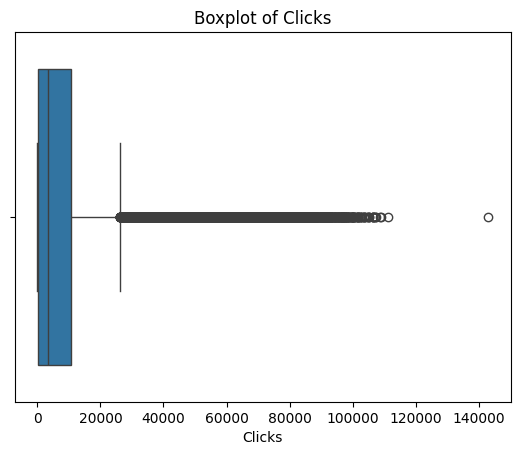

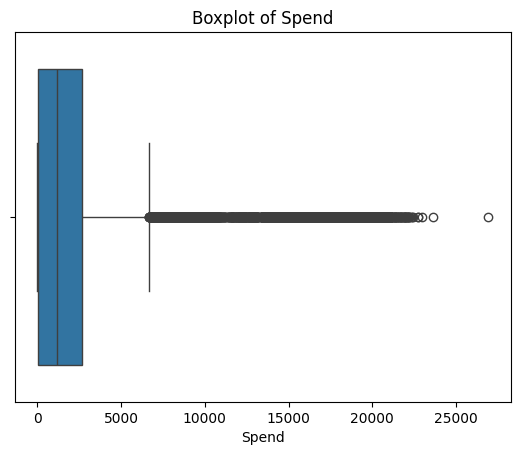

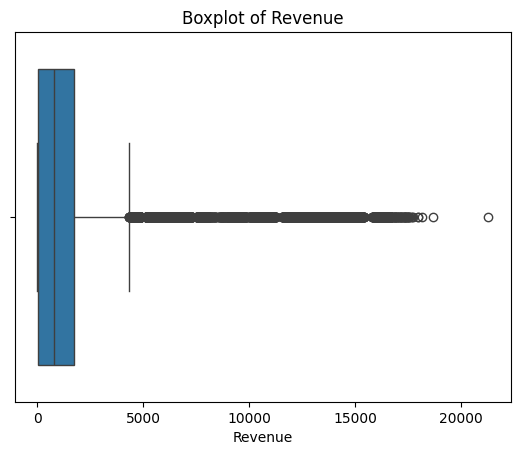

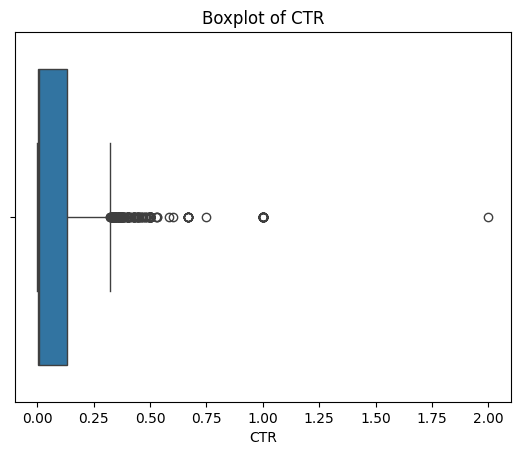

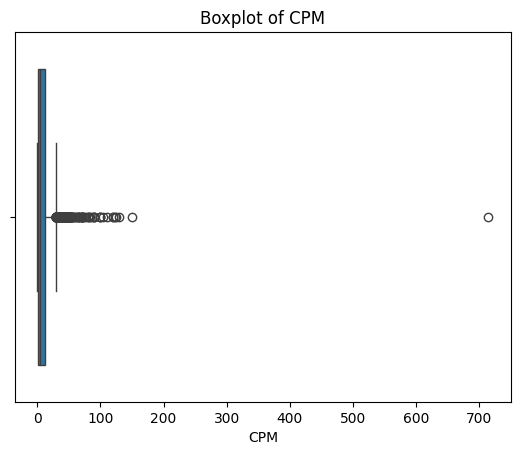

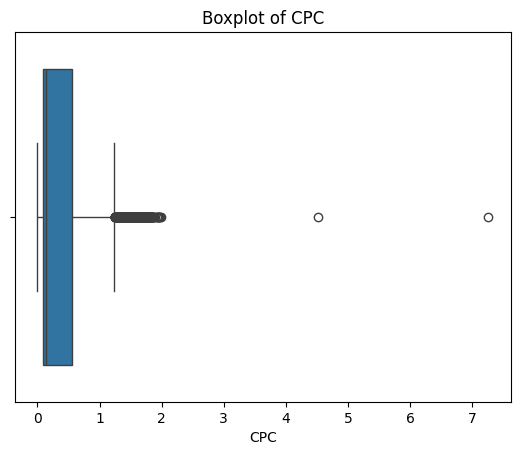

In [ ]:
cluster_vars = ['Clicks', 'Spend', 'Revenue', 'CTR', 'CPM', 'CPC']

for col in cluster_vars:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
# Quantifying the outliers with IQR rule for each clustering variable
outlier_summary = {}
for col in cluster_vars:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

pd.Series(outlier_summary, name="outlier_count")

Clicks     2093
Spend      2459
Revenue    2626
CTR         299
CPM         229
CPC         568
Name: outlier_count, dtype: int64

**Decision:** We choose not to remove or cap outliers before clustering.

Reasoning: We keep these high-spend rows on purpose. They're real premium campaigns, not errors, and exactly what we want K-Means to find. Instead of removing them, we standardize the data so no single metric overpowers the rest just because of its units. This pays off later: one of the final clusters turns out to be exactly this high-spend, high-revenue group.

## 4. Z-score scaling as per assignment instructions

We standardize each clustering variable to mean 0, standard deviation 1 (`StandardScaler`).

**Effect on algorithm speed:** K-Means keeps re-measuring distances and re-centering clusters until things settle. If one feature (like Spend, in the thousands) is on a much bigger scale than another (like CTR, a small fraction), it dominates those distance calculations, and the centroids take longer to settle into place. Z-score scaling puts every feature on the same footing, so the algorithm converges faster and as a bonus, it stops big-unit features like Spend from unfairly outweighing the others just because of their scale.

In [ ]:
# Only cluster on rows with complete data across all six clustering variables
df_cluster = df.dropna(subset=cluster_vars).copy()
print("Rows available for clustering:", len(df_cluster))

X_scaled = StandardScaler().fit_transform(df_cluster[cluster_vars])

Rows available for clustering: 23066


## 5. Hierarchical clustering by using Dendrogram (Ward, Euclidean)

Ward linkage on the full (approximately) 23k rows is computationally very expensive (hierarchical clustering
scales roughly O(n^2) in memory/time). We use a fixed random sample of 1,000 rows purely to make
the dendrogram legible and fast to compute. This sample is used only for the dendrogram
visualization below, not for the final K-Means clustering, which uses the full dataset.

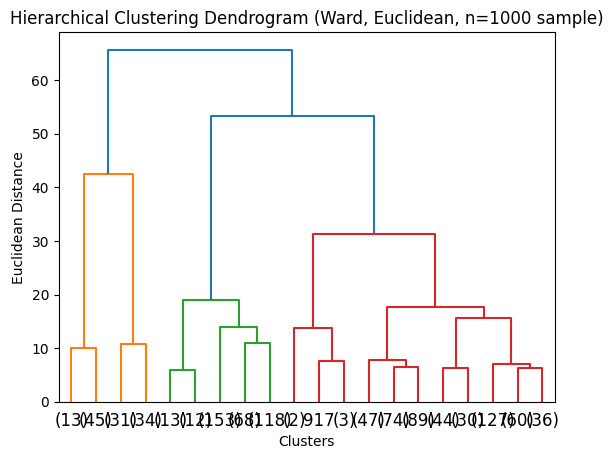

In [ ]:
np.random.seed(42)
X_sample = X_scaled[np.random.choice(len(X_scaled), min(1000, len(X_scaled)), replace=False)]

linked = linkage(X_sample, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram (Ward, Euclidean, n=1000 sample)")
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")
plt.show()

## 6. Elbow plot and Silhouette scores

Both are computed on the full standardized dataset (not the dendrogram's sample) so the number
of clusters we select is representative of the whole population.

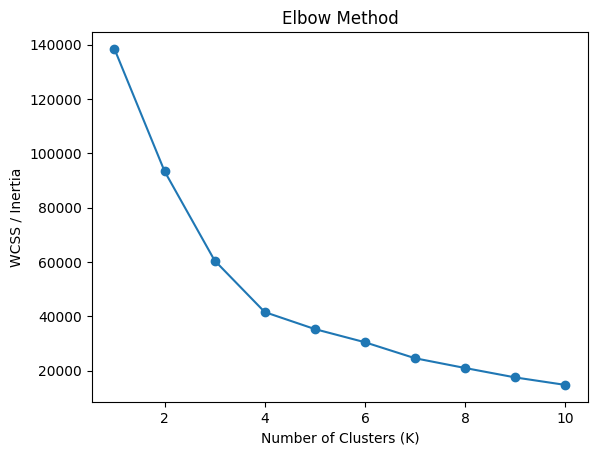

In [ ]:
# Elbow method: WCSS / inertia for k = 1..10
inertia = []
for k in range(1, 11):
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.show()

K = 2, Silhouette Score = 0.4259


K = 3, Silhouette Score = 0.4934


K = 4, Silhouette Score = 0.5392


K = 5, Silhouette Score = 0.5006


K = 6, Silhouette Score = 0.5069


K = 7, Silhouette Score = 0.5040


K = 8, Silhouette Score = 0.4104


K = 9, Silhouette Score = 0.4798


K = 10, Silhouette Score = 0.4510


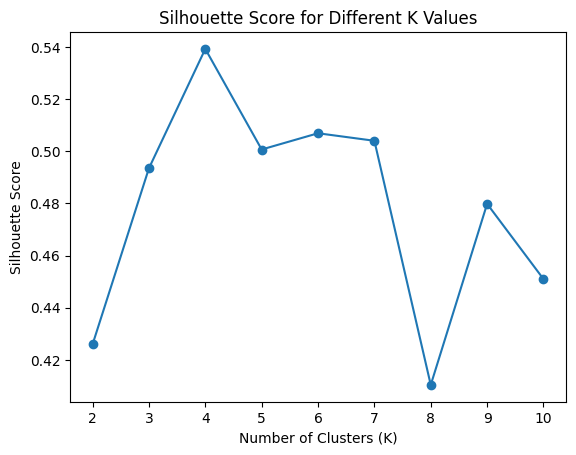

In [ ]:
# Silhouette score for k = 2..10 (k=1 is undefined for silhouette)
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

In [ ]:
best_k = list(range(2, 11))[np.argmax(silhouette_scores)]
print("Optimum number of clusters (highest silhouette score):", best_k)

Optimum number of clusters (highest silhouette score): 4


## 7. Final K-Means clustering

We fit the final model once, using "best_k" selected above, on the full standardized dataset.
This is the single clustering used for every profile, table and chart from here on. Earlier
exploratory runs are not reused, so there is no mismatch between the numbers below and the charts.

In [ ]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cluster['Cluster'] = final_kmeans.fit_predict(X_scaled)

print(df_cluster['Cluster'].value_counts().sort_index())

Cluster
0     8976
1    11330
2     1375
3     1385
Name: count, dtype: int64


In [ ]:
# Profiling Clusters
cluster_summary = df_cluster.groupby('Cluster')[cluster_vars].mean().round(2)
cluster_summary

,Clicks,Spend,Revenue,CTR,CPM,CPC
Cluster,,,,,,
0,4528.19,2466.78,1654.20,0.00,1.71,0.59
1,7422.86,695.02,453.73,0.15,13.67,0.10
2,69897.43,7329.72,5283.22,0.14,15.37,0.11
3,18379.52,16127.27,12369.36,0.00,1.71,0.91


In [ ]:
# Device Type mix within each cluster (row-normalized)
device_mix = pd.crosstab(df_cluster['Cluster'], df_cluster['Device Type'], normalize='index').round(2)
device_mix

Device Type,Desktop,Mobile
Cluster,,
0,0.36,0.64
1,0.36,0.64
2,0.36,0.64
3,0.35,0.65


Device Type mix is very close to the same Desktop/Mobile split (~35-36% / 64-65%) in every
cluster, so Device Type is not a variable that meaningfully separates the clusters here. The
clusters are being driven by engagement behaviour, not by which device the ad ran on. We
still show the breakdown by device below as the brief requests, but we are calling this out rather than
imply a device-driven story that isn't in the data.

### Bar charts: each clustering variable by Cluster and Device Type

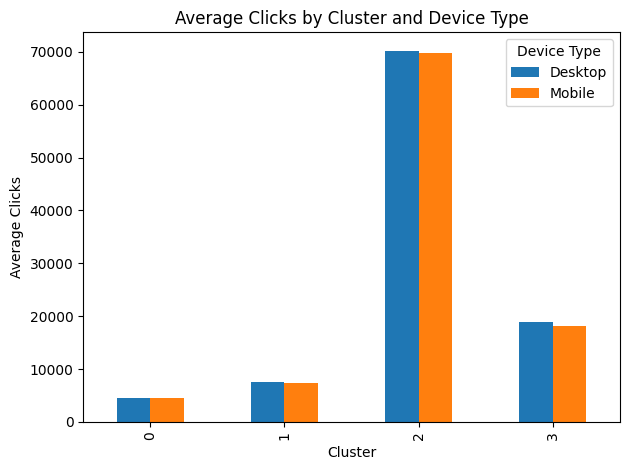

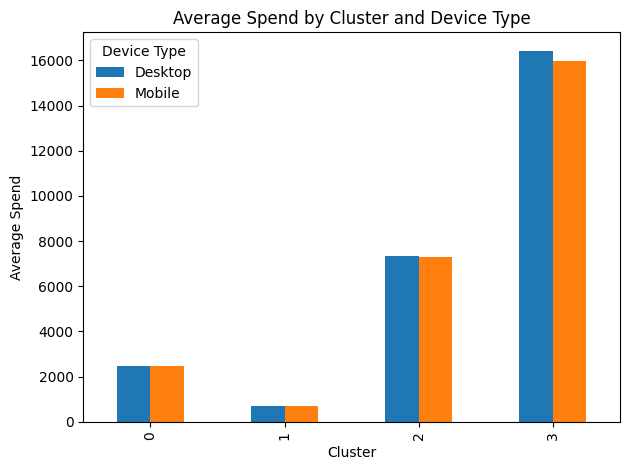

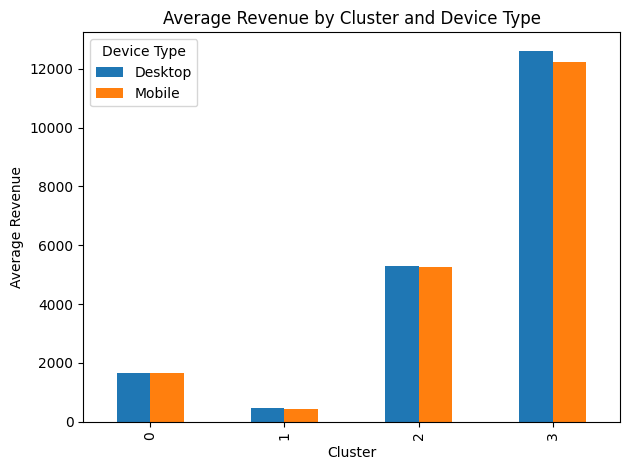

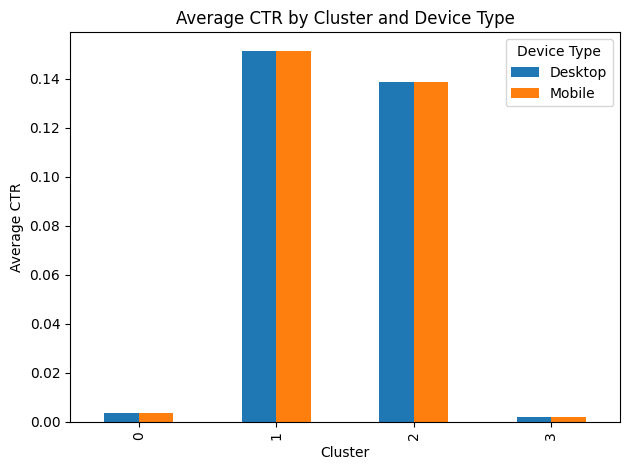

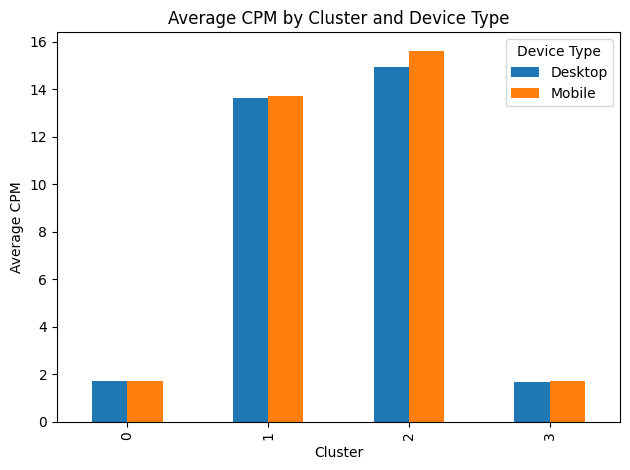

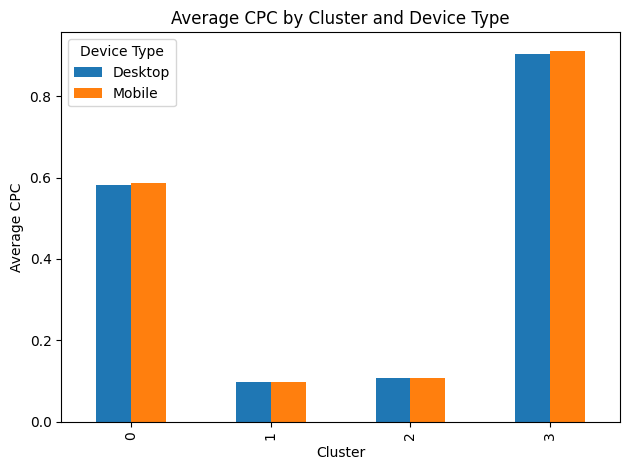

In [ ]:
for col in cluster_vars:
    plot_data = df_cluster.groupby(['Cluster', 'Device Type'])[col].mean().unstack()
    plot_data.plot(kind='bar')
    plt.title(f"Average {col} by Cluster and Device Type")
    plt.xlabel("Cluster")
    plt.ylabel(f"Average {col}")
    plt.tight_layout()
    plt.show()

## 8. Hierarchical vs. K-Means (method choice and justification)

Both methods were run: Ward hierarchical clustering (on a 1,000-row sample, for interpretability)
and K-Means (on the full approximately 23k rows). **We use K-Means for the final segmentation**, for three
reasons:

1. **Scale.** Hierarchical/Ward clustering's distance-matrix computation does not scale to
   23,000+ rows in reasonable time/memory; it only remains usable here on a small sample. K-Means'
   per-iteration cost scales linearly with the number of points, so it is the only one of the two
   we can run on the entire dataset without losing information.
2. **Objective, quantitative cluster count.** K-Means combined with the elbow plot and (more
   decisively) the silhouette score gives a numeric basis for choosing k=4, whereas the dendrogram
   only supports a visual read of where to cut.
3. **Consistency check.** The dendrogram (on the sample) still shows a broadly similar structure
   of well-separated large groups, which is a useful sanity check that the K-Means result on the
   full data isn't an artifact of that specific algorithm and both approaches agree there is real
   cluster structure, and K-Means is the practical choice for producing the final labels used in
   this report.

## 9. Cluster profiles and business recommendations

**Cluster 0  (Low-value, unresponsive inventory)**
Low clicks, moderate spend, very low revenue, near-zero CTR, low CPM, but the second-highest CPC.
Money is going out with almost nothing coming back in clicks or revenue.

*Recommendation:* Pause or renegotiate this inventory. If it can't be paused, cap daily spend and
audit targeting/creative. This segment is close to wasted budget.

**Cluster 1  (Small-scale, efficient inventory)**
Best CTR and lowest CPC of all clusters, but low spend and low revenue.

*Recommendation:* This is the clearest scale-up candidate: the efficiency is proven, so
increasing budget here should convert into revenue growth without hurting CPC/CTR
efficiency, assuming the same audience/inventory is available at higher volume.

**Cluster 2  (High-volume, efficient performer)**
By far the highest click volume, strong CTR, low CPC, and the highest revenue of any cluster.

*Recommendation:* This is the core, high-performing segment — protect and prioritize its budget
allocation, and use it as the benchmark (creative, targeting, inventory type) when trying to
improve the other clusters.

**Cluster 3 (Premium, high-cost inventory)**
Highest spend and highest revenue, but the lowest CTR and highest CPC. It earns the most revenue
in absolute terms, but at a much higher cost per outcome than Cluster 2.

*Recommendation:* Revenue-positive, so don't cut it, but investigate why CPC is so much higher
here relative to Cluster 2 (inventory type, competition for the placement, bidding strategy).
Even a modest CPC improvement on this much spend has an outsized effect on overall margin.

## 10. Conclusion — summary of learnings

- Digital ad inventory in this dataset separates into four behaviourally distinct groups, driven
  by spend, click volume and cost-efficiency rather than by device type.
- One cluster (0) is effectively unproductive spend and is the clearest candidate for budget
  reallocation; one cluster (1) is small but efficient and is the clearest scale-up candidate.
- The single largest revenue driver (Cluster 2) is also the most cost-efficient, which is the
  strongest evidence in the data of what "good" inventory looks like for this business.
- Cluster 3 shows that high spend and high revenue don't necessarily mean high efficiency. It is
  the most valuable cluster in absolute revenue, but also the most expensive per outcome, and is
  where margin improvement work should be focused first.
- Methodologically: z-score scaling was necessary for K-Means to treat all six variables fairly
  and to converge efficiently; outliers were deliberately retained because they represent a real,
  economically meaningful segment (Cluster 3) rather than data errors; and K-Means was chosen over
  hierarchical clustering for the final analysis mainly because it scales to the full dataset and
  gives an objective, silhouette-based basis for choosing the number of clusters.